In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt

In [5]:
files_a = sorted(glob.glob("skupina_a/*.png"))
files_b = sorted(glob.glob("skupina_b/*.png"))

skupina_a = [plt.imread(f)[:, :, 0] for f in files_a]
skupina_b = [plt.imread(f)[:, :, 0] for f in files_b]

print("A:", len(skupina_a))
print("B:", len(skupina_b))

A: 5
B: 5


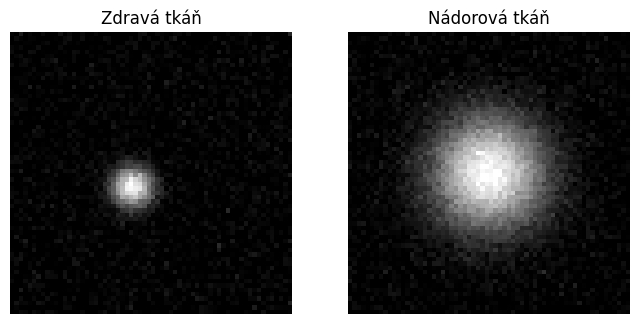

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(skupina_a[0], cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Zdravá tkáň")
ax[0].axis("off")

ax[1].imshow(skupina_b[0], cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Nádorová tkáň")
ax[1].axis("off")

plt.show()

In [7]:
PRAH = 0.5
snimek = skupina_a[0]

maska = snimek > PRAH

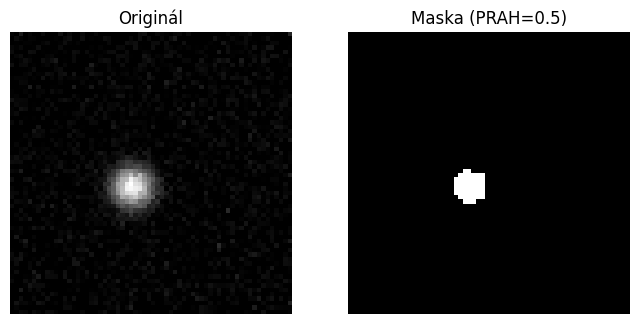

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(snimek, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Originál")
ax[0].axis("off")

ax[1].imshow(maska, cmap="gray")
ax[1].set_title(f"Maska (PRAH={PRAH})")
ax[1].axis("off")

plt.show()

In [9]:
podil = maska.sum() / maska.size * 100
mean_int = snimek[maska].mean()

print(f"Plocha struktury: {podil:.1f} %")
print(f"Průměrná intenzita: {mean_int:.3f}")

Plocha struktury: 1.1 %
Průměrná intenzita: 0.714


In [10]:
PRAH = 0.5

def spocitej_podil(img):
    maska = img > PRAH
    return maska.sum() / maska.size * 100

podily_a = [spocitej_podil(img) for img in skupina_a]
podily_b = [spocitej_podil(img) for img in skupina_b]

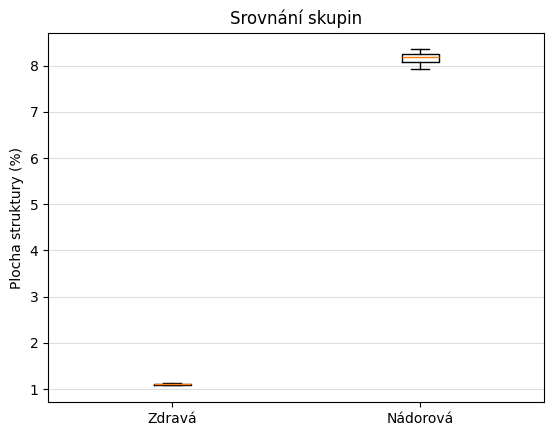

In [11]:
plt.boxplot([podily_a, podily_b], tick_labels=["Zdravá", "Nádorová"])
plt.ylabel("Plocha struktury (%)")
plt.title("Srovnání skupin")
plt.grid(True, axis="y", alpha=0.4)
plt.show()

In [12]:
print("Skupina A:", [f"{p:.1f} %" for p in podily_a])
print("Skupina B:", [f"{p:.1f} %" for p in podily_b])

Skupina A: ['1.1 %', '1.1 %', '1.1 %', '1.1 %', '1.1 %']
Skupina B: ['8.1 %', '8.3 %', '8.3 %', '7.9 %', '8.2 %']


Skupina B (nádorová tkáň) má výrazně větší plochu struktury než skupina A (zdravá tkáň). Rozdíl je viditelný i na grafech, ale kvantitativní analýza ho potvrzuje přesněji. V reálné praxi by výsledky mohly ovlivnit šum, rozdílné osvětlení nebo artefakty v obraze.